<a href="https://colab.research.google.com/github/kev461/SDSS_Astronomico_patrones_atipicos/blob/main/BD_260313_SDSS_Astronomico_patrones_atipicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install synapseml

In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import Column
from pyspark.sql.functions import col,sum,avg,min,max,when
import seaborn as sns


# DataSet Astronomico

In [ ]:
from google.colab import files
files.upload()

Base de datos usada:

SDSS PhotoObj (objID, ra, dec, modelMag_u, modelMag_g, modelMag_r, modelMag_i, modelMag_z)
Saque 500.000 filas e hice 4 peticiones, luego las uni.

Planteamiento:

Detectar objetos astronómicos con valores extremos de magnitudes y colores utilizando Isolation Forest. Con el Isolation forest hacer un analisis de anomalias grafico ubicando las categorias por combinacion de colores g-r y u-g (colores extremadamente rojos o azules, magnitudes absurdas o combinaciones raras), y analizar su distribución espacial (ra, dec) para identificar patrones raros.

In [ ]:
from pyspark.ml.feature import VectorAssembler
from synapse.ml.isolationforest import IsolationForest

spark = SparkSession.builder \
    .appName("SDSS_Outliers") \
    .config("spark.jars.packages", "com.microsoft.azure:synapseml_2.12:0.11.4") \
    .getOrCreate()
#Se simula HDFS de manera simple, en el dataframe medica (Covid) se ve de manera un poco más fiel
ruta_local = "file:///content/SDSS_analisisespacial.csv"
'''
Si fuera real ser[ia: dfSDSS = spark.read.csv("hdfs://namenode:8020/user/tu_usuario/SDSS_analisisespacial.csv",
                        header=True, inferSchema=True)
'''
dfSDSS = spark.read.csv(ruta_local, header=True, inferSchema=True)
dfSDSS.show(5)

+-------------------+----------------+----------------+----------+----------+----------+----------+----------+
|              objID|              ra|             dec|modelMag_u|modelMag_g|modelMag_r|modelMag_i|modelMag_z|
+-------------------+----------------+----------------+----------+----------+----------+----------+----------+
|1237646794379821507|91.7170508890139| 1.4168126941854|  21.34923|  18.02754|  16.66341|  16.09332|   15.8787|
|1237646794379821508|91.7011398838292| 1.4014700263371|  19.97371|  17.62079|  16.59673|  16.17404|  16.00086|
|1237646794379821509|91.7079180444871|1.42050852955518|  18.83393|  17.28821|  16.61694|  16.30943|  16.22531|
|1237646794379821595|91.7083161806454| 1.2677541274858|  18.51933|  17.05509|  16.39725|  16.11167|   16.0035|
|1237646794379821600|91.7110251892084|1.27670480946308|  18.38558|  16.80475|  16.27816|  15.96424|  15.98532|
+-------------------+----------------+----------------+----------+----------+----------+----------+----------+
o

## Analisis

In [ ]:
dfSDSS.printSchema()

root
 |-- objID: long (nullable = true)
 |-- ra: double (nullable = true)
 |-- dec: double (nullable = true)
 |-- modelMag_u: double (nullable = true)
 |-- modelMag_g: double (nullable = true)
 |-- modelMag_r: double (nullable = true)
 |-- modelMag_i: double (nullable = true)
 |-- modelMag_z: double (nullable = true)



In [ ]:
dfSDSS.columns

['objID',
 'ra',
 'dec',
 'modelMag_u',
 'modelMag_g',
 'modelMag_r',
 'modelMag_i',
 'modelMag_z']

In [ ]:
dfSDSS.describe().show()

+-------+--------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|               objID|                ra|               dec|        modelMag_u|        modelMag_g|        modelMag_r|        modelMag_i|        modelMag_z|
+-------+--------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|  count|             2000000|           2000000|           2000000|           2000000|           2000000|           2000000|           2000000|           2000000|
|   mean|1.237659956154986...|182.94438561318904|14.926773199446716|20.281180928159916|18.642814851929995|17.721260593324775| 17.03742284884947|17.060350457610166|
| stddev|1.022938148554444E13|118.49717982265952|18.779165912344173|12.544062476742512|18.953354608700554|2.5509585127812047|53.997607974140145| 24.66418175786789|
|    min| 123764

In [ ]:
#Revisión de nulos

#El cast hace que el booleano se lea como 1 o 0 al sumarlo es que da la la suma de la condicion por columna
dfSDSS.select([
    sum(col(columna).isNull().cast("int")).alias(columna)
    for columna in dfSDSS.columns
]).show()
#Se puede ver que no hay nulos en la base de datos astronómica

+-----+---+---+----------+----------+----------+----------+----------+
|objID| ra|dec|modelMag_u|modelMag_g|modelMag_r|modelMag_i|modelMag_z|
+-----+---+---+----------+----------+----------+----------+----------+
|    0|  0|  0|         0|         0|         0|         0|         0|
+-----+---+---+----------+----------+----------+----------+----------+



In [ ]:
#Las columnas que mas interesan analizar son las magnitudes, que representan cantidad de brillo
columnasSDSS = ["modelMag_u", "modelMag_g", "modelMag_r", "modelMag_i","modelMag_z"]

In [ ]:
print("Valores minimos")
dfSDSS.select([min(col(c)).alias(c) for c in columnasSDSS]).show()
#Los valores -9999 son valores no obtenidos, o errores
#Para sacar un promedio no son utiles, pero si para el Isolation Forest

Valores minimos
+----------+----------+----------+----------+----------+
|modelMag_u|modelMag_g|modelMag_r|modelMag_i|modelMag_z|
+----------+----------+----------+----------+----------+
|   -9999.0|   -9999.0|  14.00001|   -9999.0|   -9999.0|
+----------+----------+----------+----------+----------+



In [ ]:
conteos = dfSDSS.select([
    sum((col(c) == -9999).cast("int")).alias(c)
    for c in columnasSDSS
])

conteos.show()
#Como la cantidad de datos es alta, se pueden eliminar las columnas con -9999, o cambiarlas como None SOLO PARA EL CALCULO DE PROMEDIOS

+----------+----------+----------+----------+----------+
|modelMag_u|modelMag_g|modelMag_r|modelMag_i|modelMag_z|
+----------+----------+----------+----------+----------+
|         3|         7|         0|        58|        12|
+----------+----------+----------+----------+----------+



In [ ]:
print("Valores máximos")
dfSDSS.select([max(col(c)).alias(c) for c in columnasSDSS]).show()

Valores máximos
+----------+----------+----------+----------+----------+
|modelMag_u|modelMag_g|modelMag_r|modelMag_i|modelMag_z|
+----------+----------+----------+----------+----------+
|  33.72129|  34.83482|   32.0541|  35.15624|  36.61831|
+----------+----------+----------+----------+----------+



In [ ]:
dfSDSS_sin9999 = dfSDSS
for c in columnasSDSS:
    dfSDSS_sin9999 = dfSDSS_sin9999.withColumn(c, when(col(c) == -9999, None).otherwise(col(c)))

print("Valores minimos sin -9999")
dfSDSS_sin9999.select([min(col(c)).alias(c) for c in columnasSDSS]).show()

Valores minimos sin -9999
+----------+----------+----------+----------+----------+
|modelMag_u|modelMag_g|modelMag_r|modelMag_i|modelMag_z|
+----------+----------+----------+----------+----------+
|  6.896918|  6.639845|  14.00001|  7.825968|  5.757881|
+----------+----------+----------+----------+----------+



In [ ]:
#Se buscará un promedio general pero de las columnas que mas nos interesan, no su posición, sino las magnitudes y sin el valor -9999

promedios_df = dfSDSS_sin9999.select([avg(c).alias(c) for c in columnasSDSS])

promedio_general = np.sum([promedios_df.select(c).first()[0] for c in columnasSDSS])/len(columnasSDSS)
promedios_df.show()
print(f"Promedio General= {promedio_general}")

+-----------------+------------------+------------------+------------------+------------------+
|       modelMag_u|        modelMag_g|        modelMag_r|        modelMag_i|        modelMag_z|
+-----------------+------------------+------------------+------------------+------------------+
|20.29620987247472|18.677876724498564|17.721260593324775|17.327896357843823|17.120447180293272|
+-----------------+------------------+------------------+------------------+------------------+

Promedio General= 18.22873814568703


In [ ]:
valorsuperior=promedio_general+16
valorinferior=promedio_general-10
df_filtradoSupeior = dfSDSS_sin9999.filter(
    (col("modelMag_u") > valorsuperior) |
    (col("modelMag_g") > valorsuperior) |
    (col("modelMag_r") > valorsuperior) |
    (col("modelMag_i") > valorsuperior) |
    (col("modelMag_z") > valorsuperior)
)

df_filtradoSupeior.show(20)

df_filtradoInferior = dfSDSS_sin9999.filter(
    (col("modelMag_u") < valorinferior) |
    (col("modelMag_g") < valorinferior) |
    (col("modelMag_r") < valorinferior) |
    (col("modelMag_i") < valorinferior) |
    (col("modelMag_z") < valorinferior)
)

df_filtradoInferior.show(20)

print(f"Cantidad de filas Filtrado Superior: {df_filtradoSupeior.count()}")
print(f"Cantidad de filas Filtrado Inferior: {df_filtradoInferior.count()}")
#En el primero filtro se tiene los objetos que probablemente sean más tenues o lejanos, o raros
#En el segundo filtro se ven los más brillantes o cercanos
#Los valores sobre 30 es de tener cuidado ya que son casi imperceptibles, pero dentro del umbral más alto no se ve que sea muy frecuente
#Si son muy brillantes o son elementos muy grandes o especiales, es de analizar

+-------------------+----------------+-------------------+----------+----------+----------+----------+----------+
|              objID|              ra|                dec|modelMag_u|modelMag_g|modelMag_r|modelMag_i|modelMag_z|
+-------------------+----------------+-------------------+----------+----------+----------+----------+----------+
|1237654187638784315|183.175479427142| -0.993573539322713|  19.23638|  34.83482|  16.87901|  16.02661|  31.21807|
|1237654188172181811|175.213542389758| -0.675524903342027|   32.0001|  19.28448|  16.57994|  34.67882|  16.06061|
|1237654189250052341|184.590410311421|  0.227860402693885|  29.76171|  16.95623|  16.44274|  34.26062|  15.14182|
|1237654190320189736|176.471830058716|   0.94960336222607|    16.552|  28.14051|   16.3206|  34.38724|  29.65378|
|1237654190321369390|179.148656212089|   1.10905291440493|  19.08885|  17.83888|    16.804|  34.35906|  16.42559|
|1237654190321369393|179.154242488041|   1.09705782082371|  18.15961|  17.36964|  16.134

## Outliers Isolation Forest

### Outliers sin Ubicacion

Se intentó hacerlo con Isolation Forest de Spark, como no resultó se convierte a Pandas y se trabaja, pero toca partirla, 2 millones de filas no es factible con Pandas

In [ ]:
muestraSDSSmag = dfSDSS.select(
    "modelMag_u",
    "modelMag_g",
    "modelMag_r",
    "modelMag_i",
    "modelMag_z"
).sample(fraction=0.4)

muestrapdSDSSmag = muestraSDSSmag.toPandas()

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.01
)

iso.fit(muestrapdSDSSmag)

IsolationForest(contamination=0.01)

In [ ]:
OUTLIERmuestrapdSDSSmag=muestrapdSDSSmag.copy()
OUTLIERmuestrapdSDSSmag["anomaly"] = iso.predict(muestrapdSDSSmag[columnasSDSS])#Se le pasan las columnas para el predict para que no hayan problemas porque estamps agregando una clasificación anomala o no
OUTLIERmuestrapdSDSSmag["score"] = iso.decision_function(muestrapdSDSSmag[columnasSDSS])#Aqui vemos que tan anomalo es realmente

In [ ]:
OUTLIERmuestrapdSDSSmag.head()

,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,anomaly,score
0,21.34923,18.02754,16.66341,16.09332,15.87870,1,0.239014
1,18.51933,17.05509,16.39725,16.11167,16.00350,1,0.261858
2,18.38558,16.80475,16.27816,15.96424,15.98532,1,0.251272
3,19.54138,17.63704,16.87289,16.43271,16.44724,1,0.271009
4,19.04258,17.39563,16.60334,16.24344,16.09943,1,0.266219


In [ ]:
OUTLIERmuestrapdSDSSmag["anomaly"].value_counts()

,count
anomaly,
1,791530
-1,7991


In [ ]:
OUTLIERmuestrapdSDSSmag.sort_values("score").head(20)

,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,anomaly,score
494016,30.67863,31.64618,31.53124,28.24981,29.55191,-1,-0.129442
43990,30.16619,30.12492,16.23707,33.18567,28.91082,-1,-0.124472
98114,32.17493,31.59423,16.20181,27.70090,29.76338,-1,-0.123419
139156,30.47876,32.27403,16.00015,30.37094,28.91995,-1,-0.122894
45656,30.53797,34.10019,16.64457,32.76338,30.01277,-1,-0.122894
154275,31.38074,30.76884,16.63353,27.99359,29.81561,-1,-0.122894
245338,31.56872,31.67430,15.90077,31.99842,29.69612,-1,-0.122894
287273,30.66562,31.18855,15.17232,29.45547,29.12322,-1,-0.122894
301380,31.07163,33.99772,15.66171,30.47074,29.90661,-1,-0.122894
266554,30.70868,33.21398,15.45453,32.52835,28.63023,-1,-0.122894


### Outliers magnitudes + ubicacion

In [ ]:
muestraSDSSUBI = dfSDSS.select(
    "ra",
    "dec",
    "modelMag_u",
    "modelMag_g",
    "modelMag_r",
    "modelMag_i",
    "modelMag_z",

).sample(fraction=0.4)

muestrapdSDSS_UBI = muestraSDSSUBI.toPandas()

In [ ]:
isoUBI = IsolationForest(
    contamination=0.01
)

iso.fit(muestrapdSDSS_UBI)

IsolationForest(contamination=0.01)

In [ ]:
OUTLIERmuestrapdSDSS_UBI=muestrapdSDSS_UBI.copy()
columnasSDSS_UBI = ["ra","dec","modelMag_u", "modelMag_g", "modelMag_r", "modelMag_i","modelMag_z"]
OUTLIERmuestrapdSDSS_UBI["anomaly"] = iso.predict(muestrapdSDSS_UBI[columnasSDSS_UBI])#Se le pasan las columnas para el predict para que no hayan problemas porque estamps agregando una clasificación anomala o no, pero creando la lista con las columnas incluyendo su ubicacion
OUTLIERmuestrapdSDSS_UBI["score"] = iso.decision_function(muestrapdSDSS_UBI[columnasSDSS_UBI])#Aqui vemos que tan anomalo es realmente

In [ ]:
OUTLIERmuestrapdSDSS_UBI.head(20)

,ra,dec,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,anomaly,score
0,91.717051,1.416813,21.34923,18.02754,16.66341,16.09332,15.87870,1,0.214268
1,91.707918,1.420509,18.83393,17.28821,16.61694,16.30943,16.22531,1,0.234068
2,91.711025,1.276705,18.38558,16.80475,16.27816,15.96424,15.98532,1,0.225268
3,172.376479,14.158367,20.41388,17.74564,16.39145,15.78259,15.48213,1,0.193333
4,172.398566,14.117236,20.38720,17.80942,16.60104,16.07555,15.80000,1,0.200911
5,243.769055,7.093195,20.35692,17.72712,16.57090,16.12805,15.88163,1,0.206606
6,304.243988,29.757676,22.88209,19.08896,16.78287,15.53025,14.65080,1,0.132484
7,158.543079,1.301643,17.76093,16.51763,16.03512,15.88326,15.79161,1,0.213698
8,158.548427,1.207592,18.91546,16.93066,16.03563,15.69136,15.46151,1,0.224702
9,152.338324,1.065425,18.61145,17.36620,16.83521,16.63668,16.51585,1,0.222948


In [ ]:
OUTLIERmuestrapdSDSS_UBI["anomaly"].value_counts()

,count
anomaly,
1,791929
-1,8000


In [ ]:
OUTLIERmuestrapdSDSS_UBI.sort_values("score").head(20)

,ra,dec,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,anomaly,score
456318,304.595862,29.590720,20.31795,33.22291,31.02994,31.60476,29.08815,-1,-0.111983
494554,304.908559,29.362010,30.67863,31.64618,31.53124,28.24981,29.55191,-1,-0.111650
154072,53.424293,14.717664,32.32552,30.99817,16.79564,32.09157,30.91705,-1,-0.111547
152069,53.414769,14.714324,31.69231,27.95347,16.37505,33.29565,30.36147,-1,-0.111547
657940,136.936608,64.991667,30.66109,32.40998,17.72885,27.98494,26.76979,-1,-0.110335
154071,53.350005,14.680129,30.03561,29.36594,16.90271,31.85554,30.73694,-1,-0.110062
418297,305.923309,28.636137,29.85455,29.69058,29.47305,28.86452,28.03675,-1,-0.109670
667533,118.618212,52.964274,30.38995,31.32542,17.21673,32.23441,28.91930,-1,-0.108480
734254,78.102857,25.709823,30.40009,32.67106,17.12120,32.48564,29.07202,-1,-0.108473
668688,118.636351,52.969847,29.48192,30.53516,17.04927,32.27597,28.79582,-1,-0.108239


### Graficos

* u-g	radiación UV
* g-r	temperatura estelar
* r-i	transición rojo-infrarrojo
* i-z	objetos fríos

In [ ]:
#Las combinaciones de colores determinan ciertos elementos del espacio, asi que se procedera a compinarlos

#Para Magnitudes sin ubicacion:
OUTLIERmuestrapdSDSSmag["u_g"] = OUTLIERmuestrapdSDSSmag["modelMag_u"] - OUTLIERmuestrapdSDSSmag["modelMag_g"]

OUTLIERmuestrapdSDSSmag["g_r"] = OUTLIERmuestrapdSDSSmag["modelMag_g"] - OUTLIERmuestrapdSDSSmag["modelMag_r"]

OUTLIERmuestrapdSDSSmag["r_i"] = OUTLIERmuestrapdSDSSmag["modelMag_r"] - OUTLIERmuestrapdSDSSmag["modelMag_i"]

OUTLIERmuestrapdSDSSmag["i_z"] = OUTLIERmuestrapdSDSSmag["modelMag_i"] - OUTLIERmuestrapdSDSSmag["modelMag_z"]

OUTLIERmuestrapdSDSSmag.head()

,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,anomaly,score,u_g,g_r,r_i,i_z
0,21.34923,18.02754,16.66341,16.09332,15.87870,1,0.239014,3.32169,1.36413,0.57009,0.21462
1,18.51933,17.05509,16.39725,16.11167,16.00350,1,0.261858,1.46424,0.65784,0.28558,0.10817
2,18.38558,16.80475,16.27816,15.96424,15.98532,1,0.251272,1.58083,0.52659,0.31392,-0.02108
3,19.54138,17.63704,16.87289,16.43271,16.44724,1,0.271009,1.90434,0.76415,0.44018,-0.01453
4,19.04258,17.39563,16.60334,16.24344,16.09943,1,0.266219,1.64695,0.79229,0.35990,0.14401


In [ ]:
#Ahora magnitudes con ubicacion:
OUTLIERmuestrapdSDSS_UBI["u_g"] = OUTLIERmuestrapdSDSS_UBI["modelMag_u"] - OUTLIERmuestrapdSDSS_UBI["modelMag_g"]

OUTLIERmuestrapdSDSS_UBI["g_r"] = OUTLIERmuestrapdSDSS_UBI["modelMag_g"] - OUTLIERmuestrapdSDSS_UBI["modelMag_r"]

OUTLIERmuestrapdSDSS_UBI["r_i"] = OUTLIERmuestrapdSDSS_UBI["modelMag_r"] - OUTLIERmuestrapdSDSS_UBI["modelMag_i"]

OUTLIERmuestrapdSDSS_UBI["i_z"] = OUTLIERmuestrapdSDSS_UBI["modelMag_i"] - OUTLIERmuestrapdSDSS_UBI["modelMag_z"]

OUTLIERmuestrapdSDSS_UBI.head()

,ra,dec,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,anomaly,score,u_g,g_r,r_i,i_z
0,91.717051,1.416813,21.34923,18.02754,16.66341,16.09332,15.87870,1,0.214268,3.32169,1.36413,0.57009,0.21462
1,91.707918,1.420509,18.83393,17.28821,16.61694,16.30943,16.22531,1,0.234068,1.54572,0.67127,0.30751,0.08412
2,91.711025,1.276705,18.38558,16.80475,16.27816,15.96424,15.98532,1,0.225268,1.58083,0.52659,0.31392,-0.02108
3,172.376479,14.158367,20.41388,17.74564,16.39145,15.78259,15.48213,1,0.193333,2.66824,1.35419,0.60886,0.30046
4,172.398566,14.117236,20.38720,17.80942,16.60104,16.07555,15.80000,1,0.200911,2.57778,1.20838,0.52549,0.27555


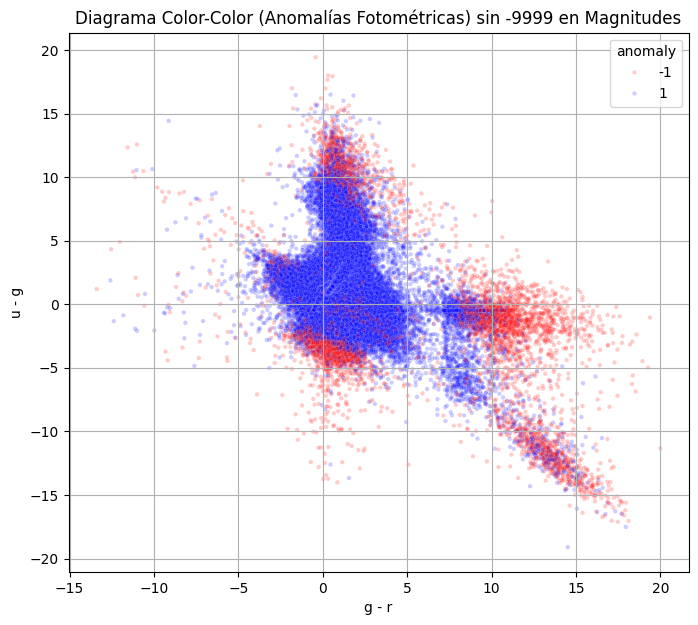

In [ ]:
#AQUI QUITAMOS LOS VALORES DE -9999

# Lista de columnas de magnitud
columnasmagnitud = ['modelMag_u', 'modelMag_g', 'modelMag_r', 'modelMag_i', 'modelMag_z']

# Cambiamos los valores de -9999 para pasarlos como nan, asi luego se hace filtracion más rapido con un dropna
dfsinnueves = OUTLIERmuestrapdSDSSmag.copy()
for col_name in columnasmagnitud:
    dfsinnueves[col_name] = dfsinnueves[col_name].replace(-9999, float('nan'))

# Aqui se eliminan de manera facil
filtrado_OUTLIERmuestrapdSDSSmag = dfsinnueves.dropna(subset=columnasmagnitud)

# Tomar una muestra del DataFrame filtrado para evitar overplotting
# muestrafiltradaconsns = filtrado_OUTLIERmuestrapdSDSSmag.sample(n=100000)
#porsi no quiero filtro solo quito el sample y es como lo grafico
muestrafiltradaconsns = filtrado_OUTLIERmuestrapdSDSSmag

plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=muestrafiltradaconsns,
    x="g_r",
    y="u_g",
    hue="anomaly",
    palette={1: 'blue', -1: 'red'},
    s=10,
    alpha=0.2,
    legend='full'
)

plt.title("Diagrama Color-Color (Anomalías Fotométricas) sin -9999 en Magnitudes")
plt.xlabel("g - r")
plt.ylabel("u - g")
plt.grid(True)
plt.show()
#Este diagrama agrupa una combinación de magnitudes (Sin contar las que tienen -9999 para este caso) para ver que combinaciones o en que sectores se forman anomalías (Color rojo). Ej: Con un g-r entre -2 y 2 y un u-g entre -5 y -3 se tienden a forman anomalías

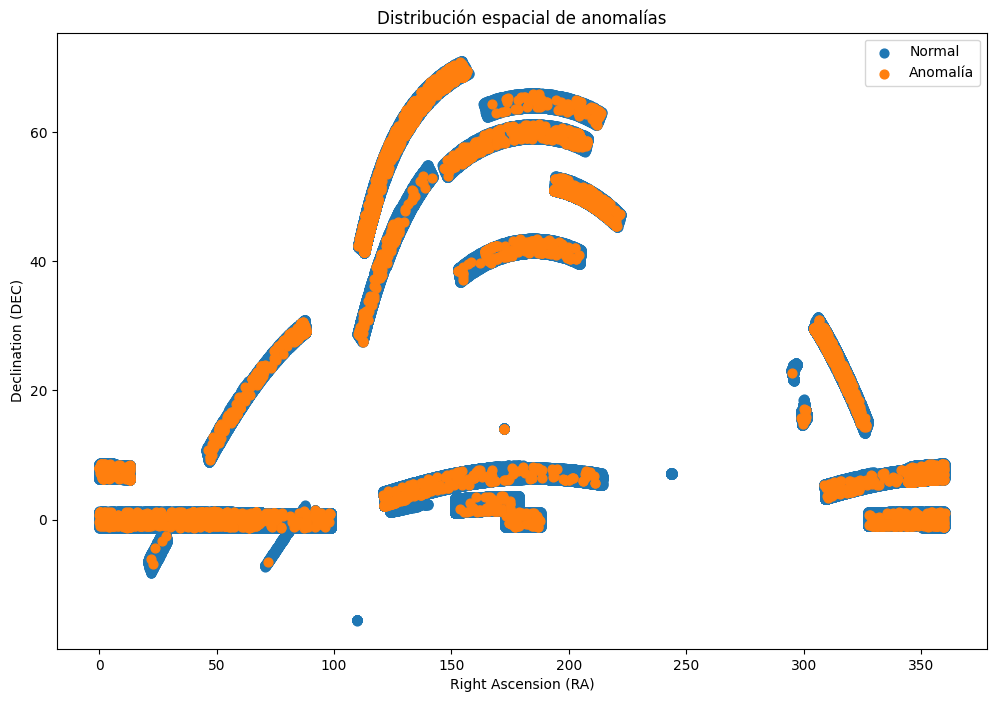

In [ ]:
sample = OUTLIERmuestrapdSDSS_UBI

normal = sample[sample["anomaly"] == 1]
outliers = sample[sample["anomaly"] == -1]
plt.figure(figsize=(12,8))

plt.scatter(normal["ra"], normal["dec"],
            s=40, label="Normal")

plt.scatter(outliers["ra"], outliers["dec"],
            s=40, label="Anomalía")

plt.xlabel("Right Ascension (RA)")
plt.ylabel("Declination (DEC)")
plt.title("Distribución espacial de anomalías")

plt.legend()
plt.show()
#Aqui clasifico de manera espacial (Ubicación), las magnitudes, y las ubicaciones con anomalías está en naranja, son un 7000, las normales 700.000, pero se ve así porque las anomalías/errores están más distribuidas

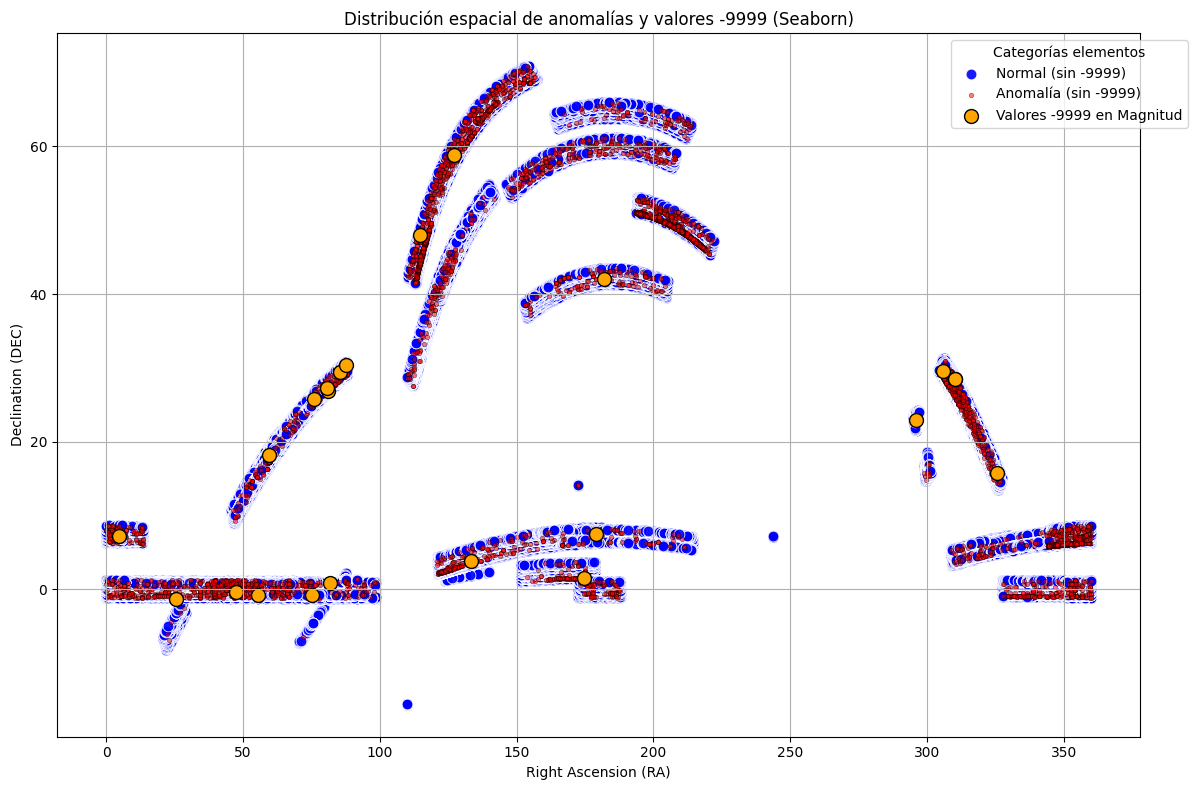

In [ ]:

df_plot = OUTLIERmuestrapdSDSS_UBI.copy()

#Por comodidad se definen de nuevo las columnas de magnitud
mag_cols = ['modelMag_u', 'modelMag_g', 'modelMag_r', 'modelMag_i', 'modelMag_z']

# Bool para identificar los que tienen algun valor en -9999, si akguna columna tiene ese valor, es verdadero, por eso es el any(axis=1), recorre por filas
tiene9999 = (df_plot[mag_cols] == -9999).any(axis=1)

# Columna de categotía
df_plot['categoria'] = 'Normal (sin -9999)'
df_plot.loc[df_plot['anomaly'] == -1, 'categoria'] = 'Anomalía (sin -9999)'
df_plot.loc[tiene9999, 'categoria'] = 'Valores -9999 en Magnitud'

plt.figure(figsize=(12, 8))

# Plot Normal points
sns.scatterplot(
    data=df_plot[df_plot['categoria'] == 'Normal (sin -9999)'],
    x='ra',
    y='dec',
    color='blue',
    s=60, # Smaller for normal points
    alpha=0.9, # More transparent for normal points
    label='Normal (sin -9999)'
)

# Plot Anomalies
sns.scatterplot(
    data=df_plot[df_plot['categoria'] == 'Anomalía (sin -9999)'],
    x='ra',
    y='dec',
    color='red',
    s=10, # Larger for anomalies
    alpha=0.5, # More opaque for anomalies
    edgecolor='black', # Add black edge for better visibility
    linewidth=0.5,
    label='Anomalía (sin -9999)'
)

# Plot -9999 points
sns.scatterplot(
    data=df_plot[df_plot['categoria'] == 'Valores -9999 en Magnitud'],
    x='ra',
    y='dec',
    color='orange',
    s=100, #Para destacar los puntos con estas caracteristicas
    alpha=1.0, # Fully opaque
    edgecolor='black',
    linewidth=1,
    label='Valores -9999 en Magnitud'
)

plt.xlabel("Right Ascension (RA)")
plt.ylabel("Declination (DEC)")
plt.title("Distribución espacial de anomalías y valores -9999 (Seaborn)")

plt.legend(title='Categorías elementos', bbox_to_anchor=(1.05, 1), loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()
#En esta caso cambio el formato, y permito graficar las anomalías con datos que tengan -9999 en alguna magnitud, esto permite un estudio para saber que pasó y porque se forman en los sectores que se formaron (Color amarillo), las anomalías sin este valor se ubicacron en rojo, aquí se puede ver mejor la sobreposición de elementos.